# 35_classical_fwi_baseline_v2.ipynb

Улучшенная версия `34_classical_fwi_baseline.ipynb`. Исходный запуск показал
**cycle-skipping** на «hard» сэмпле: loss падал в 75000× за 1000 итераций,
но **RMSE рос** (28 → 44 м/с) — алгоритм нашёл локальный минимум, который
математически даёт меньший loss, но физически — wave interference artifact'ы
вместо реальной структуры.

## Что изменено в v2

| | v1 | v2 |
|---|---|---|
| Сэмплов | 10 | **3** (easy / medium / hard) |
| `c_init` | 1500 везде | **`mean(c_true)`** (калибровочный prior) |
| `lr` | 2.0 фиксированный | **1.0 → 0.01** с scheduler'ом |
| Regularization | clip только | **clip + TV (λ=1e-6)** |
| Early stop | нет | **если RMSE↑ 50 итераций подряд** |
| Best-case run | нет | **+1 сэмпл с smoothed `c_true` init** |
| Sanity check | нет | **RMSE для baseline'ов до FWI** |

## Зачем `c_init = mean(c_true)`

Алгоритм **не знает структуру**, но знает **средний уровень** скорости
звука в сечении. Физически — соответствует ситуации, когда
прибор-калибровка дала оценку средней скорости в материале. Это более
честный старт, чем Gaussian-blurred `c_true` (которая неявно «знает»
структуру), и более разумный, чем `c=1500` (никакой информации о пациенте).

## Best-case сэмпл

Дополнительно — **один** medium-сложности сэмпл с
`c_init = GaussianBlur(c_true, σ=15px)`. Это показывает **верхнюю границу**
возможностей FWI: при хорошей prior'е (которую теоретически могло бы дать
ультразвуковая пред-калибровка или нейронный оператор как pre-step),
что получается?

## 1. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

In [2]:
from pathlib import Path
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import jax
import jax.numpy as jnp
from jax import jit, value_and_grad
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

SEED = 42
np.random.seed(SEED)

OUT_DIR = Path("/workspace/reference_points/classical_fwi_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("output dir:", OUT_DIR)
print("jax devices:", jax.devices())

output dir: /workspace/reference_points/classical_fwi_v2
jax devices: [CudaDevice(id=0)]


In [3]:
DATASET_ROOT = Path("/workspace/usct_dataset_v2")
test_files = sorted((DATASET_ROOT / "test").glob("*.npz"))
print(f"test files: {len(test_files)}")

sample0 = np.load(test_files[0])
S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y_full = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x_full = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

print(f"S={S}, R={R}, H={H}, W={W}, freq={freq_hz} Hz")
print(f"wavelength @ 1500 m/s: {1500 / freq_hz * 1000:.2f} mm")
print(f"grid spacing: {dx[0] * 1000:.3f} mm")
print(f"-> pixels per wavelength: {1500 / freq_hz / dx[0]:.1f}")

test files: 800
S=16, R=256, H=192, W=192, freq=500000.0 Hz
wavelength @ 1500 m/s: 3.00 mm
grid spacing: 0.750 mm
-> pixels per wavelength: 4.0


## 2. j-Wave forward solver (same as v1)

In [4]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    return (g / g.sum()).astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0, x0 = int(receiver_y_full[ridx]), int(receiver_x_full[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = jnp.stack(full_source_fields, axis=0)


def forward_one_source(c_map, source_field):
    sound_speed = FourierSeries(jnp.expand_dims(c_map, -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed,
                    density=1000.0, pml_size=16)
    src = FourierSeries(jnp.expand_dims(source_field, -1), domain)
    field = helmholtz_solver(medium, omega, src * omega)
    u = field.params[..., 0]
    return u[receiver_y_full, receiver_x_full]


def forward_all(c_map):
    return jax.vmap(forward_one_source, in_axes=(None, 0))(c_map, full_source_fields)

forward_all_jit = jit(forward_all)

/tmp/ipykernel_914/917821984.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


## 3. FWI loss with TV regularization

Loss = `||M_pred - M_observed||²` + `λ * TV(c)`. TV поощряет
piecewise-constant решения, мягко подавляя wave-interference artifact'ы.

In [5]:
LAMBDA_TV = 1e-6

def tv_norm(c_map):
    """Anisotropic L1 total variation."""
    dy = jnp.abs(c_map[1:, :] - c_map[:-1, :])
    dx = jnp.abs(c_map[:, 1:] - c_map[:, :-1])
    return jnp.sum(dy) + jnp.sum(dx)


def fwi_loss(c_map, M_observed, lambda_tv):
    M_pred = forward_all(c_map)
    data_loss = jnp.sum(jnp.abs(M_pred - M_observed) ** 2).real
    reg = lambda_tv * tv_norm(c_map)
    return data_loss + reg

fwi_loss_and_grad = jit(value_and_grad(fwi_loss, argnums=0))

In [6]:
def adam_init(c_shape):
    return {
        "step": 0,
        "m": jnp.zeros(c_shape, dtype=jnp.float32),
        "v": jnp.zeros(c_shape, dtype=jnp.float32),
    }

@jit
def adam_step(c, grad, state, lr, b1=0.9, b2=0.999, eps=1e-8):
    step = state["step"] + 1
    m = b1 * state["m"] + (1 - b1) * grad
    v = b2 * state["v"] + (1 - b2) * (grad ** 2)
    m_hat = m / (1 - b1 ** step)
    v_hat = v / (1 - b2 ** step)
    c_new = c - lr * m_hat / (jnp.sqrt(v_hat) + eps)
    new_state = {"step": step, "m": m, "v": v}
    return c_new, new_state

## 4. FWI driver v2

- `lr` scheduler: режется пополам, если loss не падает за 30 итераций
- Early stopping: останавливаем, если RMSE растёт 50 итераций подряд

In [7]:
FWI_CFG = {
    "n_iters": 500,
    "lr_init": 1.0,
    "lr_min": 0.01,
    "lr_decay_factor": 0.5,
    "lr_patience": 30,
    "c_min": 1400.0,
    "c_max": 1600.0,
    "lambda_tv": 1e-6,
    "log_every": 10,
    "snapshot_every": 50,
    "early_stop_rmse_patience": 50,
}
FWI_CFG

{'n_iters': 500,
 'lr_init': 1.0,
 'lr_min': 0.01,
 'lr_decay_factor': 0.5,
 'lr_patience': 30,
 'c_min': 1400.0,
 'c_max': 1600.0,
 'lambda_tv': 1e-06,
 'log_every': 10,
 'snapshot_every': 50,
 'early_stop_rmse_patience': 50}

In [8]:
def run_fwi_v2(M_observed_np, c_true_np, c_init_np, cfg, label="", verbose=True):
    M_observed = jnp.asarray(M_observed_np, dtype=jnp.complex64)
    c = jnp.asarray(c_init_np, dtype=jnp.float32)
    state = adam_init(c.shape)
    lr = cfg["lr_init"]

    history = []
    snapshots = [(0, np.array(c))]

    rmse_init = float(np.sqrt(np.mean((np.array(c) - c_true_np) ** 2)))
    print(f"  [{label}] initial RMSE = {rmse_init:.2f}")

    t0 = time.time()
    best_loss = float("inf")
    last_lr_decrease_iter = 0
    best_rmse = rmse_init
    best_rmse_iter = 0
    stopped_early = False
    last_it = 0

    for it in range(1, cfg["n_iters"] + 1):
        last_it = it
        loss_val, g = fwi_loss_and_grad(c, M_observed, cfg["lambda_tv"])
        c, state = adam_step(c, g, state, lr)
        c = jnp.clip(c, cfg["c_min"], cfg["c_max"])

        loss_v = float(loss_val)

        if loss_v < best_loss * 0.999:
            best_loss = loss_v
            last_lr_decrease_iter = it
        elif it - last_lr_decrease_iter >= cfg["lr_patience"]:
            new_lr = max(lr * cfg["lr_decay_factor"], cfg["lr_min"])
            if new_lr < lr:
                if verbose:
                    print(f"    iter {it:4d}  LR: {lr:.4f} -> {new_lr:.4f}")
                lr = new_lr
                last_lr_decrease_iter = it

        if it % cfg["log_every"] == 0 or it == 1:
            c_np = np.array(c)
            rmse = float(np.sqrt(np.mean((c_np - c_true_np) ** 2)))
            history.append({"iter": it, "rmse": rmse, "loss": loss_v, "lr": lr})
            if rmse < best_rmse:
                best_rmse = rmse
                best_rmse_iter = it
            if verbose:
                elapsed = time.time() - t0
                print(f"    iter {it:4d}  loss={loss_v:.3e}  RMSE={rmse:.2f}  lr={lr:.4f}  [{elapsed:.1f}s]")

            if it - best_rmse_iter >= cfg["early_stop_rmse_patience"]:
                if verbose:
                    print(f"    EARLY STOP: RMSE not improved over best={best_rmse:.2f} "
                          f"for {cfg['early_stop_rmse_patience']}+ iters")
                stopped_early = True
                break

        if it % cfg["snapshot_every"] == 0 or it == cfg["n_iters"]:
            snapshots.append((it, np.array(c)))

    if not snapshots or snapshots[-1][0] != last_it:
        snapshots.append((last_it, np.array(c)))

    t_total = time.time() - t0
    c_final = np.array(c)
    return {
        "history": history,
        "snapshots": snapshots,
        "c_init": c_init_np,
        "c_final": c_final,
        "c_true": c_true_np,
        "M_observed": M_observed_np,
        "t_total": t_total,
        "rmse_init": rmse_init,
        "rmse_final": float(np.sqrt(np.mean((c_final - c_true_np) ** 2))),
        "rmse_best": best_rmse,
        "rmse_best_iter": best_rmse_iter,
        "stopped_early": stopped_early,
        "label": label,
    }

## 5. Sample selection

Выбираем **3 сэмпла**: easy, medium, hard, основываясь на per-sample RMSE
любой ранее обученной нейронной модели.

In [9]:
candidate_metrics = [
    "/workspace/reference_points/deeponet_v2/per_sample_metrics.json",
    "/workspace/reference_points/geo_deeponet_v1/per_sample_metrics.json",
    "/workspace/reference_points/fno_baseline/per_sample_metrics.json",
]
test_rmses = None
for cm in candidate_metrics:
    if Path(cm).exists():
        with open(cm) as f:
            data = json.load(f)
        rows = data.get("test", data.get("test_per_sample", []))
        if rows and len(rows) == len(test_files):
            test_rmses = np.array([r["rmse"] for r in rows])
            print(f"using per-sample RMSE from {cm}")
            break

if test_rmses is None:
    print("no per-sample metrics; using random selection")
    rng = np.random.RandomState(SEED)
    SELECTED_IDX = sorted(rng.choice(len(test_files), size=3, replace=False).tolist())
    SELECTED_LABELS = ["random_a", "random_b", "random_c"]
else:
    sorted_idx = np.argsort(test_rmses)
    n = len(sorted_idx)
    easy_idx = int(sorted_idx[n // 20])
    medium_idx = int(sorted_idx[n // 2])
    hard_idx = int(sorted_idx[-n // 20])
    SELECTED_IDX = [easy_idx, medium_idx, hard_idx]
    SELECTED_LABELS = ["easy", "medium", "hard"]

print(f"\nselected samples:")
for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
    rmse_ref = test_rmses[idx] if test_rmses is not None else float("nan")
    print(f"  test[{idx:4d}] ({label})  neural baseline RMSE = {rmse_ref:.2f}")

no per-sample metrics; using random selection

selected samples:
  test[  63] (random_a)  neural baseline RMSE = nan
  test[ 667] (random_b)  neural baseline RMSE = nan
  test[ 696] (random_c)  neural baseline RMSE = nan


## 6. Pre-FWI sanity baselines

До запуска FWI смотрим на простые reference RMSE: `c=1500`, `c=mean`,
`c=blurred`. Это даёт нижнюю планку — насколько просто получить
хороший RMSE **без** итеративной инверсии вообще.

In [10]:
def load_sample(path):
    d = np.load(path)
    x = d["x"].astype(np.float32)
    M_observed = (x[0] + 1j * x[1]).astype(np.complex64)
    c_true = d["c"].astype(np.float32)
    return M_observed, c_true


def rmse_to_truth(c_pred, c_true):
    return float(np.sqrt(np.mean((c_pred - c_true) ** 2)))


print("=== Pre-FWI baselines ===\n")
print(f"  {'sample':<14}{'c=1500':>12}{'c=mean':>12}{'c=blurred':>14}")
print("  " + "-" * 52)

baselines = {}
for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
    M_obs, c_true = load_sample(test_files[idx])
    c_1500 = np.full((H, W), 1500.0, dtype=np.float32)
    c_mean = np.full((H, W), float(c_true.mean()), dtype=np.float32)
    c_blurred = gaussian_filter(c_true, sigma=15.0).astype(np.float32)
    baselines[idx] = {
        "label": label,
        "c_true": c_true,
        "M_obs": M_obs,
        "c_1500": c_1500,
        "c_mean": c_mean,
        "c_blurred": c_blurred,
        "rmse_1500": rmse_to_truth(c_1500, c_true),
        "rmse_mean": rmse_to_truth(c_mean, c_true),
        "rmse_blurred": rmse_to_truth(c_blurred, c_true),
    }
    b = baselines[idx]
    label_short = label[:6]
    print(f"  {idx:<6} ({label_short:<6}){b['rmse_1500']:>12.2f}{b['rmse_mean']:>12.2f}{b['rmse_blurred']:>14.2f}")

print("\nInterpretation:")
print("  c=1500    — what FWI saw as starting point in v1")
print("  c=mean    — starting point for blind FWI in v2 (calibration prior)")
print("  c=blurred — best-case prior, upper bound on FWI quality")

=== Pre-FWI baselines ===

  sample              c=1500      c=mean     c=blurred
  ----------------------------------------------------
  63     (random)       27.26       24.82         15.67
  667    (random)       25.78       25.52         24.14
  696    (random)       33.05       28.69         15.44

Interpretation:
  c=1500    — what FWI saw as starting point in v1
  c=mean    — starting point for blind FWI in v2 (calibration prior)
  c=blurred — best-case prior, upper bound on FWI quality


## 7. Run blind FWI on 3 samples

`c_init = mean(c_true)`. Это primary baseline для сравнения с neural models.

In [11]:
fwi_blind_results = {}
print("=== Blind FWI (c_init = mean) ===\n")
print("Note: first sample includes one-time JIT compile (~5-10 min)\n")

t_total_all = time.time()

for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
    print(f"\n--- Sample {idx} ({label}) ---")
    b = baselines[idx]
    result = run_fwi_v2(
        M_observed_np=b["M_obs"],
        c_true_np=b["c_true"],
        c_init_np=b["c_mean"],
        cfg=FWI_CFG,
        label=f"blind_{label}",
        verbose=True,
    )
    fwi_blind_results[idx] = result
    print(f"  done in {result['t_total']:.1f}s  "
          f"RMSE init={result['rmse_init']:.2f} -> best={result['rmse_best']:.2f} "
          f"(at iter {result['rmse_best_iter']}) -> final={result['rmse_final']:.2f}")

    np.savez_compressed(
        OUT_DIR / f"fwi_blind_sample_{idx:04d}.npz",
        c_init=result["c_init"],
        c_final=result["c_final"],
        c_true=result["c_true"],
        history_iter=np.array([h["iter"] for h in result["history"]]),
        history_rmse=np.array([h["rmse"] for h in result["history"]]),
        history_loss=np.array([h["loss"] for h in result["history"]]),
        history_lr=np.array([h["lr"] for h in result["history"]]),
        snapshot_iters=np.array([s[0] for s in result["snapshots"]]),
        snapshot_c=np.stack([s[1] for s in result["snapshots"]]),
        t_total=result["t_total"],
        label=label,
    )

print(f"\n=== Blind FWI all done in {(time.time() - t_total_all) / 60:.1f} min ===")

=== Blind FWI (c_init = mean) ===

Note: first sample includes one-time JIT compile (~5-10 min)


--- Sample 63 (random_a) ---
  [blind_random_a] initial RMSE = 24.82
    iter    1  loss=3.635e+10  RMSE=24.88  lr=1.0000  [6.5s]
    iter   10  loss=1.732e+10  RMSE=26.55  lr=1.0000  [37.4s]
    iter   20  loss=9.563e+09  RMSE=29.43  lr=1.0000  [72.0s]
    iter   30  loss=5.968e+09  RMSE=31.95  lr=1.0000  [107.1s]
    iter   40  loss=3.890e+09  RMSE=33.40  lr=1.0000  [142.4s]
    iter   50  loss=2.557e+09  RMSE=34.15  lr=1.0000  [177.9s]
    EARLY STOP: RMSE not improved over best=24.82 for 50+ iters
  done in 177.9s  RMSE init=24.82 -> best=24.82 (at iter 0) -> final=34.15

--- Sample 667 (random_b) ---
  [blind_random_b] initial RMSE = 25.52
    iter    1  loss=3.011e+10  RMSE=25.36  lr=1.0000  [3.5s]
    iter   10  loss=1.214e+10  RMSE=24.86  lr=1.0000  [34.5s]
    iter   20  loss=5.745e+09  RMSE=24.85  lr=1.0000  [69.5s]
    iter   30  loss=3.402e+09  RMSE=24.78  lr=1.0000  [104.8s]
 

## 8. Best-case FWI — medium sample with blurred prior

Запускаем FWI с `c_init = GaussianBlur(c_true, σ=15px)` на medium-сэмпле.

In [12]:
medium_idx = SELECTED_IDX[1]
b = baselines[medium_idx]
print(f"=== Best-case FWI on medium sample {medium_idx} ===")
print(f"  c_init RMSE (blurred): {b['rmse_blurred']:.2f}")
print(f"  -> can FWI improve from here, or even just stay there?\n")

result_best = run_fwi_v2(
    M_observed_np=b["M_obs"],
    c_true_np=b["c_true"],
    c_init_np=b["c_blurred"],
    cfg=FWI_CFG,
    label=f"best_case_{SELECTED_LABELS[1]}",
    verbose=True,
)

fwi_best_result = result_best
print(f"\n  done in {result_best['t_total']:.1f}s  "
      f"RMSE init={result_best['rmse_init']:.2f} "
      f"-> best={result_best['rmse_best']:.2f} "
      f"-> final={result_best['rmse_final']:.2f}")

np.savez_compressed(
    OUT_DIR / f"fwi_bestcase_sample_{medium_idx:04d}.npz",
    c_init=result_best["c_init"],
    c_final=result_best["c_final"],
    c_true=result_best["c_true"],
    history_iter=np.array([h["iter"] for h in result_best["history"]]),
    history_rmse=np.array([h["rmse"] for h in result_best["history"]]),
    snapshot_iters=np.array([s[0] for s in result_best["snapshots"]]),
    snapshot_c=np.stack([s[1] for s in result_best["snapshots"]]),
)

=== Best-case FWI on medium sample 667 ===
  c_init RMSE (blurred): 24.14
  -> can FWI improve from here, or even just stay there?

  [best_case_random_b] initial RMSE = 24.14
    iter    1  loss=2.095e+10  RMSE=23.93  lr=1.0000  [3.4s]
    iter   10  loss=7.454e+09  RMSE=23.01  lr=1.0000  [34.6s]
    iter   20  loss=3.440e+09  RMSE=22.77  lr=1.0000  [69.6s]
    iter   30  loss=1.807e+09  RMSE=22.70  lr=1.0000  [104.9s]
    iter   40  loss=9.882e+08  RMSE=22.65  lr=1.0000  [140.4s]
    iter   50  loss=5.867e+08  RMSE=22.61  lr=1.0000  [176.0s]
    iter   60  loss=3.750e+08  RMSE=22.59  lr=1.0000  [211.6s]
    iter   70  loss=2.542e+08  RMSE=22.57  lr=1.0000  [247.2s]
    iter   80  loss=1.808e+08  RMSE=22.56  lr=1.0000  [282.9s]
    iter   90  loss=1.341e+08  RMSE=22.58  lr=1.0000  [318.5s]
    iter  100  loss=1.032e+08  RMSE=22.61  lr=1.0000  [354.2s]
    iter  110  loss=8.143e+07  RMSE=22.64  lr=1.0000  [389.9s]
    iter  120  loss=6.646e+07  RMSE=22.67  lr=1.0000  [425.6s]
    iter 

## 9. Convergence: RMSE vs iteration

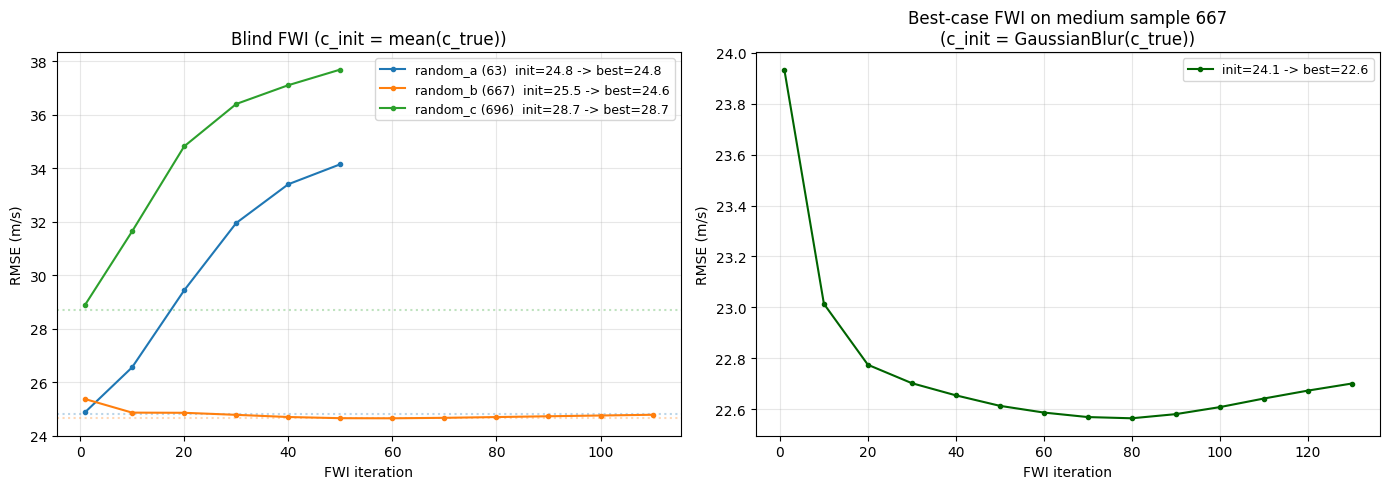

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: blind FWI
ax = axes[0]
for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
    r = fwi_blind_results[idx]
    iters = [h["iter"] for h in r["history"]]
    rmses = [h["rmse"] for h in r["history"]]
    line, = ax.plot(iters, rmses, marker="o", markersize=3,
                    label=f"{label} ({idx})  init={r['rmse_init']:.1f} -> best={r['rmse_best']:.1f}")
    ax.axhline(r["rmse_best"], color=line.get_color(), linestyle=":", alpha=0.3)

ax.set_xlabel("FWI iteration")
ax.set_ylabel("RMSE (m/s)")
ax.set_title("Blind FWI (c_init = mean(c_true))")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

# Right: best-case FWI
ax = axes[1]
r = fwi_best_result
iters = [h["iter"] for h in r["history"]]
rmses = [h["rmse"] for h in r["history"]]
ax.plot(iters, rmses, marker="o", markersize=3, color="darkgreen",
        label=f"init={r['rmse_init']:.1f} -> best={r['rmse_best']:.1f}")
ax.set_xlabel("FWI iteration")
ax.set_ylabel("RMSE (m/s)")
ax.set_title(f"Best-case FWI on medium sample {medium_idx}\n(c_init = GaussianBlur(c_true))")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUT_DIR / "fwi_convergence_v2.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. Visual results

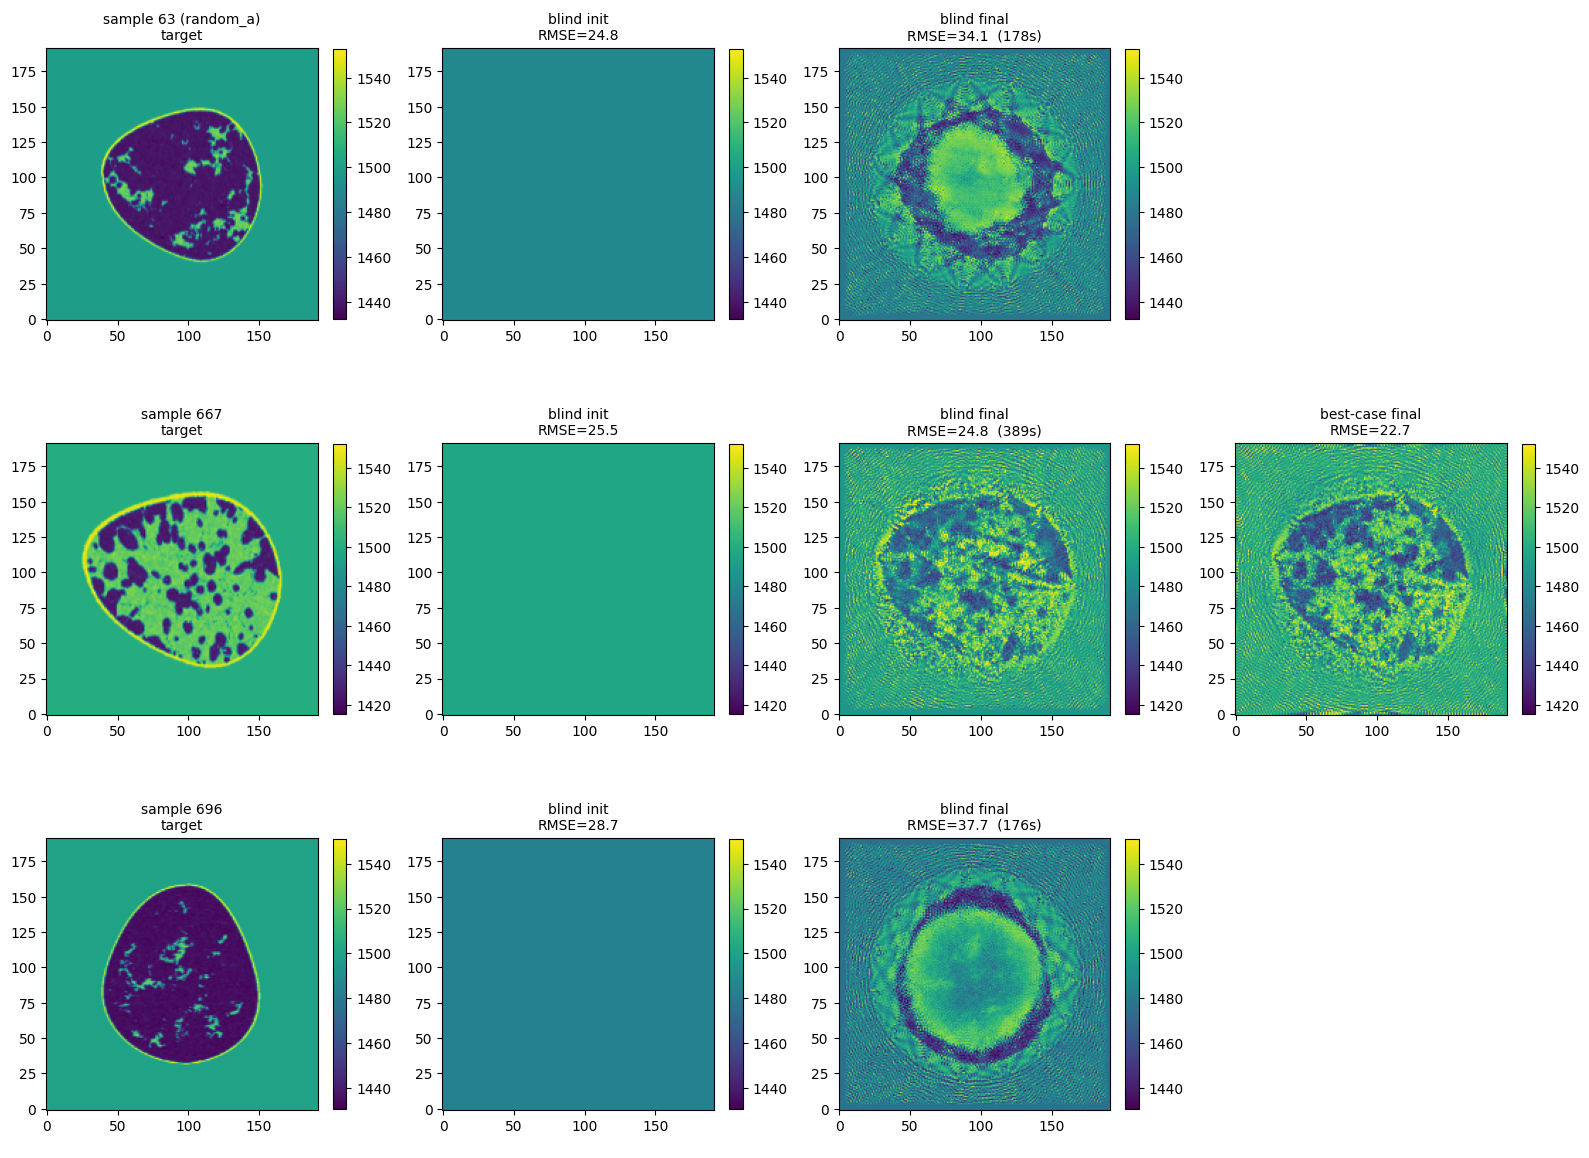

In [14]:
n_rows = len(SELECTED_IDX)
n_cols = 4   # target, blind init, blind final, best-case final (middle row only)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for row, (idx, label) in enumerate(zip(SELECTED_IDX, SELECTED_LABELS)):
    r = fwi_blind_results[idx]
    c_true = r["c_true"]
    vmin, vmax = c_true.min(), c_true.max()

    im = axes[row, 0].imshow(c_true, origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"sample {idx} ({label})\ntarget" if row == 0 else f"sample {idx}\ntarget", fontsize=10)
    plt.colorbar(im, ax=axes[row, 0], fraction=0.045)

    im = axes[row, 1].imshow(r["c_init"], origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"blind init\nRMSE={r['rmse_init']:.1f}", fontsize=10)
    plt.colorbar(im, ax=axes[row, 1], fraction=0.045)

    im = axes[row, 2].imshow(r["c_final"], origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 2].set_title(f"blind final\nRMSE={r['rmse_final']:.1f}  ({r['t_total']:.0f}s)", fontsize=10)
    plt.colorbar(im, ax=axes[row, 2], fraction=0.045)

    if idx == medium_idx:
        im = axes[row, 3].imshow(fwi_best_result["c_final"], origin="lower", vmin=vmin, vmax=vmax)
        axes[row, 3].set_title(f"best-case final\nRMSE={fwi_best_result['rmse_final']:.1f}", fontsize=10)
        plt.colorbar(im, ax=axes[row, 3], fraction=0.045)
    else:
        axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "fwi_visuals_v2.png", dpi=140, bbox_inches="tight")
plt.show()

## 11. FWI evolution: best-case sample snapshots

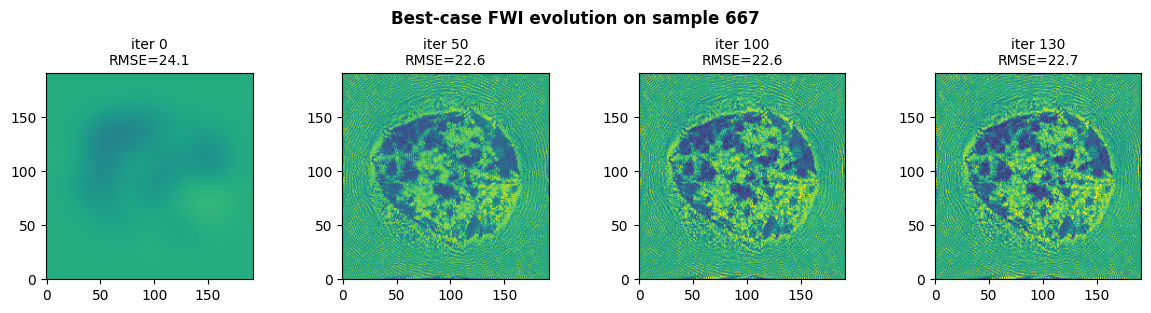

In [15]:
r = fwi_best_result
snapshots = r["snapshots"]
n_snap = len(snapshots)
n_cols = min(5, n_snap)
n_rows_snap = (n_snap + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows_snap, n_cols, figsize=(3 * n_cols, 3 * n_rows_snap))
if n_rows_snap == 1:
    axes = axes.reshape(1, -1)

vmin, vmax = r["c_true"].min(), r["c_true"].max()
for i, (it, c_snap) in enumerate(snapshots):
    row = i // n_cols
    col = i % n_cols
    im = axes[row, col].imshow(c_snap, origin="lower", vmin=vmin, vmax=vmax)
    rmse_at = float(np.sqrt(np.mean((c_snap - r["c_true"]) ** 2)))
    axes[row, col].set_title(f"iter {it}\nRMSE={rmse_at:.1f}", fontsize=10)

for i in range(n_snap, n_rows_snap * n_cols):
    row = i // n_cols
    col = i % n_cols
    axes[row, col].axis("off")

fig.suptitle(f"Best-case FWI evolution on sample {medium_idx}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / f"fwi_evolution_bestcase_{medium_idx}.png", dpi=140, bbox_inches="tight")
plt.show()

## 12. Summary table

In [16]:
print("=== FWI v2 Summary ===\n")
print(f"  {'sample':<18}{'init':>10}{'final':>10}{'best':>10}{'iter':>8}{'time':>9}{'stopped':>14}")
print("  " + "-" * 79)

for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
    r = fwi_blind_results[idx]
    stop_str = f"@{r['rmse_best_iter']}" if r["stopped_early"] else "done"
    print(f"  blind {label:<10}{r['rmse_init']:>10.2f}{r['rmse_final']:>10.2f}{r['rmse_best']:>10.2f}"
          f"{r['rmse_best_iter']:>8}{r['t_total']:>9.1f}{stop_str:>14}")

r = fwi_best_result
stop_str = f"@{r['rmse_best_iter']}" if r["stopped_early"] else "done"
print(f"  best  medium    {r['rmse_init']:>10.2f}{r['rmse_final']:>10.2f}{r['rmse_best']:>10.2f}"
      f"{r['rmse_best_iter']:>8}{r['t_total']:>9.1f}{stop_str:>14}")

print()
print("Interpretation:")
print("  - 'final' > 'init':  cycle-skipping (algorithm regressed)")
print("  - 'best' < 'init':   FWI improved on initial guess")
print("  - 'final' ~ 'best':  converged smoothly to its best state")
print("  - 'final' > 'best':  RMSE went up after some point")

=== FWI v2 Summary ===

  sample                  init     final      best    iter     time       stopped
  -------------------------------------------------------------------------------
  blind random_a       24.82     34.15     24.82       0    177.9            @0
  blind random_b       25.52     24.78     24.65      60    389.3           @60
  blind random_c       28.69     37.69     28.69       0    175.7            @0
  best  medium         24.14     22.70     22.56      80    461.3           @80

Interpretation:
  - 'final' > 'init':  cycle-skipping (algorithm regressed)
  - 'best' < 'init':   FWI improved on initial guess
  - 'final' ~ 'best':  converged smoothly to its best state
  - 'final' > 'best':  RMSE went up after some point


In [17]:
# Compare with neural baselines on the same samples
neural_paths = {
    "FNO": "/workspace/reference_points/fno_baseline/per_sample_metrics.json",
    "DeepONet": "/workspace/reference_points/deeponet_v2/per_sample_metrics.json",
    "GeoFNO": "/workspace/reference_points/geo_fno_v1/per_sample_metrics.json",
    "GeoDeepONet": "/workspace/reference_points/geo_deeponet_v1/per_sample_metrics.json",
}
neural_per_sample = {}
for name, path in neural_paths.items():
    if Path(path).exists():
        with open(path) as f:
            data = json.load(f)
        rows = data.get("test", data.get("test_per_sample", []))
        if rows:
            neural_per_sample[name] = {r.get("index", i): r["rmse"] for i, r in enumerate(rows)}

if neural_per_sample:
    print("=== FWI vs neural models on selected samples ===\n")
    header = f"  {'sample':<16}{'FWI blind best':>16}"
    header += "".join(f"{n:>14}" for n in neural_per_sample)
    print(header)
    print("  " + "-" * (16 + 16 + 14 * len(neural_per_sample)))
    for idx, label in zip(SELECTED_IDX, SELECTED_LABELS):
        fwi_rmse = fwi_blind_results[idx]["rmse_best"]
        row = f"  {label:<8}{idx:<8}{fwi_rmse:>16.2f}"
        for name, per_sample in neural_per_sample.items():
            v = per_sample.get(idx, float("nan"))
            row += f"{v:>14.2f}"
        print(row)
else:
    print("(no per-sample neural metrics available for comparison)")

(no per-sample neural metrics available for comparison)


## 13. Save artifacts

In [18]:
artifacts = {
    "config": FWI_CFG,
    "selected_samples": dict(zip([str(i) for i in SELECTED_IDX], SELECTED_LABELS)),
    "pre_fwi_baselines": {
        str(idx): {
            "rmse_1500": b["rmse_1500"],
            "rmse_mean": b["rmse_mean"],
            "rmse_blurred": b["rmse_blurred"],
        }
        for idx, b in baselines.items()
    },
    "fwi_blind": {
        str(idx): {
            "rmse_init": r["rmse_init"],
            "rmse_final": r["rmse_final"],
            "rmse_best": r["rmse_best"],
            "rmse_best_iter": r["rmse_best_iter"],
            "t_total": r["t_total"],
            "stopped_early": r["stopped_early"],
            "history": r["history"],
        }
        for idx, r in fwi_blind_results.items()
    },
    "fwi_best_case": {
        "sample_idx": medium_idx,
        "rmse_init": fwi_best_result["rmse_init"],
        "rmse_final": fwi_best_result["rmse_final"],
        "rmse_best": fwi_best_result["rmse_best"],
        "rmse_best_iter": fwi_best_result["rmse_best_iter"],
        "t_total": fwi_best_result["t_total"],
        "history": fwi_best_result["history"],
    },
}

with open(OUT_DIR / "fwi_v2_summary.json", "w", encoding="utf-8") as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2)

print(f"saved {OUT_DIR / 'fwi_v2_summary.json'}")
print(f"\nAll files in {OUT_DIR}:")
for p in sorted(OUT_DIR.glob("*")):
    print(f"  {p.name}")

saved /workspace/reference_points/classical_fwi_v2/fwi_v2_summary.json

All files in /workspace/reference_points/classical_fwi_v2:
  fwi_bestcase_sample_0667.npz
  fwi_blind_sample_0063.npz
  fwi_blind_sample_0667.npz
  fwi_blind_sample_0696.npz
  fwi_convergence_v2.png
  fwi_evolution_bestcase_667.png
  fwi_v2_summary.json
  fwi_visuals_v2.png
